In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import scipy.stats as stats
import astropy

In [2]:
datapath = '../../data/work/mwm/0.4.0/'

In [3]:
os.listdir(datapath)

['arMADGICS_out_x_starLines_v0.h5',
 'arMADGICS_out_x_starLines_restFrame_v0.h5',
 'arMADGICS_out_flux.h5',
 'arMADGICS_out_x_starLines_err_v0.h5',
 'arMADGICS_out_fluxivar.h5',
 'arMADGICS_out_x_starLineCof_v0.h5',
 'arMADGICS_out_apVisit_v0.h5',
 'public']

In [4]:
os.listdir(datapath+'public/')

['fiber_offsets.csv',
 'bad_nights.csv',
 'allVisitRV_README.md',
 'allExposure_pass1_dr21.h5',
 'rv_railed.csv',
 'offtarget_exposures.csv',
 'RECOMMENDED_CUTS.md',
 'FIBER_OFFSETS_TABLE.md',
 'allVisitRV_pass1_dr21.h5',
 'bad_fibers.csv']

In [5]:
#open the exposure file

exposure_data = h5py.File(f"{datapath}public/allExposure_pass1_dr21.h5")

###print out the possible keys available
# for key in exposure_data.keys():
#     print(key)

#grab all the SDSS IDs
sdss_id = np.array(exposure_data["sdss_id"])

#choose an ID that I want to look at
curr_id = 94846885

match_id = np.where(sdss_id == curr_id)[0]
print(f'Found N={len(match_id)} entries for sdss_id={curr_id}')

#use the matched rows to pull out relevant information for all observations of that ID
ra = exposure_data["ra"][match_id]
dec = exposure_data["dec"][match_id]

tele = exposure_data["tele"][match_id] #which telescope, apo or lco
mjd = exposure_data["mjd"][match_id] #mjd of observation
mjd_mid_exposure = exposure_data["mjd_mid_exposure"][match_id] #high precision time of observation, units of MJD
expnum = exposure_data["expnum"][match_id] #exposure number from that night
adjfiberindx = exposure_data["adjfiberindx"][match_id] #adjusted fiber index for different observations
snr = exposure_data["snr"][match_id] #signal to noise ratio of spectral observation
seeing = exposure_data["seeing"][match_id] #seeing
category = exposure_data["category"][match_id]

RV_pixoff_final = exposure_data["RV_pixoff_final"][match_id]
v_rad = exposure_data["v_rad"][match_id] #radial velocity, km/s
e_v_rad = exposure_data["e_v_rad"][match_id] #uncertainty in vrad, km/s
v_rad = exposure_data["v_rad"][match_id] #radial velocity, km/s
e_v_rad = exposure_data["e_v_rad"][match_id] #uncertainty in vrad, km/s

v_barycentric_correction = exposure_data["v_barycentric_correction"][match_id]
v_rad_corr = exposure_data["v_rad_corr"][match_id] #corrected radial velocity, km/s
v_rad_corr_flag = exposure_data["v_rad_corr_flag"][match_id] #corrected radial velocity flags

#useful flags on data/spectra quality
ingest_bit = exposure_data["ingestBit"][match_id]
RV_flag = exposure_data["RV_flag"][match_id]
bary_flag = exposure_data["bary_flag"][match_id]
off_target = exposure_data["offtarget"][match_id]
qa_bitmask = exposure_data["qa_bitmask"][match_id]

#recommended cuts on flags
good_data = (ingest_bit == 0) &\
            (RV_flag == 0) &\
            (bary_flag == 0) &\
            (off_target == 0) &\
            (qa_bitmask == 0)

#close the exposure file
exposure_data.close()


Found N=74 entries for sdss_id=94846885


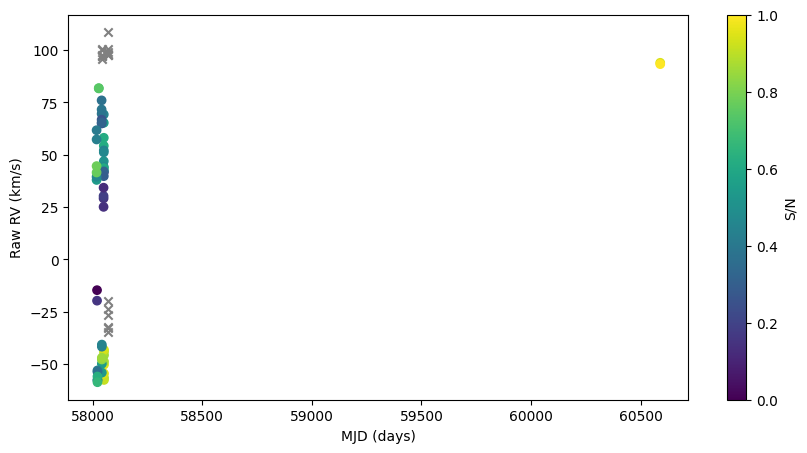

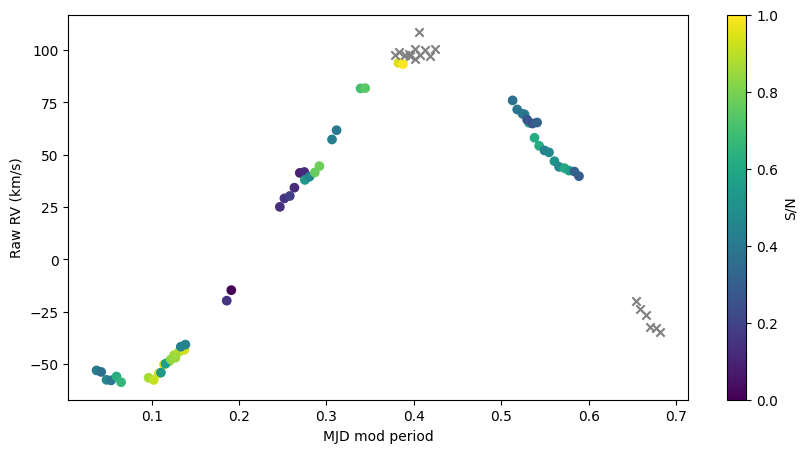

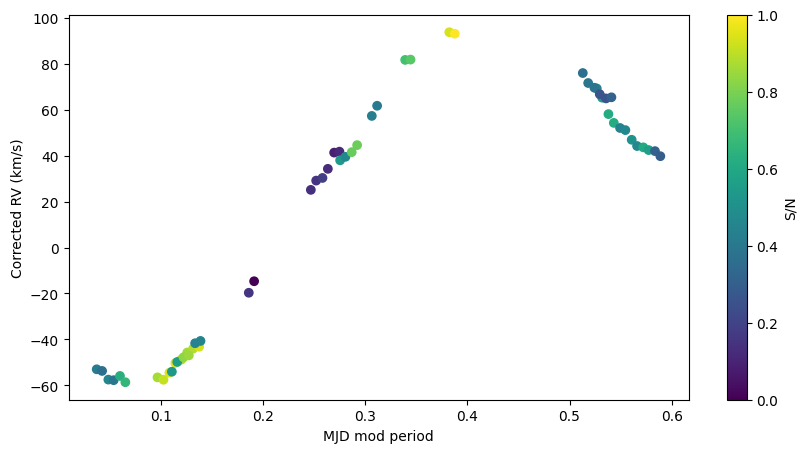

In [6]:
#choose a period, in days, for phase folding the radial velocities
period = 0.709

plt.figure(figsize=(10,5))
plt.scatter(mjd_mid_exposure[good_data],v_rad[good_data],c=snr[good_data])
plt.scatter(mjd_mid_exposure[~good_data],v_rad[~good_data],c='grey',marker='x')
plt.colorbar(label='S/N')
plt.xlabel('MJD (days)')
plt.ylabel('Raw RV (km/s)')
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(mjd_mid_exposure[good_data]%period,v_rad[good_data],c=snr[good_data])
plt.scatter(mjd_mid_exposure[~good_data]%period,v_rad[~good_data],c='grey',marker='x')
plt.colorbar(label='S/N')
plt.xlabel('MJD mod period')
plt.ylabel('Raw RV (km/s)')
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(mjd_mid_exposure[good_data]%period,v_rad_corr[good_data],c=snr[good_data])
plt.scatter(mjd_mid_exposure[~good_data]%period,v_rad_corr[~good_data],c='grey',marker='x')
plt.colorbar(label='S/N')
plt.xlabel('MJD mod period')
plt.ylabel('Corrected RV (km/s)')
plt.show()


In [7]:
#  	0 	No problems
# 0 	1 	reference array pixels
# 1 	2 	reference pixels
# 2 	4 	bad reference pixels
# 3 	8 	pixels not dark corrected
# 4 	16 	pixels with negative dark current
# 5 	32 	pixels with large dark current
# 6 	64 	flat response too low
# 7 	128 	one diff was dropped because it is a likely cosmic ray
# 8 	256 	more than one diff was dropped because they were likely cosmic rays (sus)
# 9 	512 	bad linear SUTR chi2
# 10 	1024 	failed 1D extraction
# 11 	2048 	no nearby good pixels in 1D extraction
# 12 	4096 	neff>10 in 1D extraction
# 13 	8192 	pixel partially saturated
# 14 	16384 	pixel fully saturated
bad_pix_bits = 8150

#default APOGEE wavelength array
length = 8700
uni_wave_APOGEE = np.power(10,np.arange(4.17825, 4.17825+(length-1)*6.0e-6, step = 6.0e-6))
x_inds = np.arange(len(uni_wave_APOGEE))

In [8]:
#read in spectra and uncertainties (raw and stellar components)

#arMADGICS_out_flux.h5 has the raw spectra
with h5py.File(f"{datapath}arMADGICS_out_flux.h5") as fp:
    raw_fluxes_obs = np.array(fp["flux"][match_id])
    
#arMADGICS_out_fluxivar.h5 has the raw spectral ivars
with h5py.File(f"{datapath}arMADGICS_out_fluxivar.h5") as fp:
    raw_fluxivars_obs = np.array(fp["fluxivar"][match_id])

#star component in the observed frame
with h5py.File(f"{datapath}arMADGICS_out_x_starLines_v0.h5") as fp:
    star_fluxes_obs = np.array(fp["x_starLines_v0"][match_id])

#star component in the rest frame
with h5py.File(f"{datapath}arMADGICS_out_x_starLines_restFrame_v0.h5") as fp:
    star_fluxes_rest = np.array(fp["x_starLines_restFrame_v0"][match_id])

#star component uncertainties
with h5py.File(f"{datapath}arMADGICS_out_x_starLines_err_v0.h5") as fp:
    star_flux_errs = np.array(fp["x_starLines_err_v0"][match_id])

#closest to sky subtracted, telluric divided, continuum normalized
with h5py.File(f"{datapath}arMADGICS_out_apVisit_v0.h5") as fp:
    apVisit_fluxes = fp["apVisit_v0"][match_id]


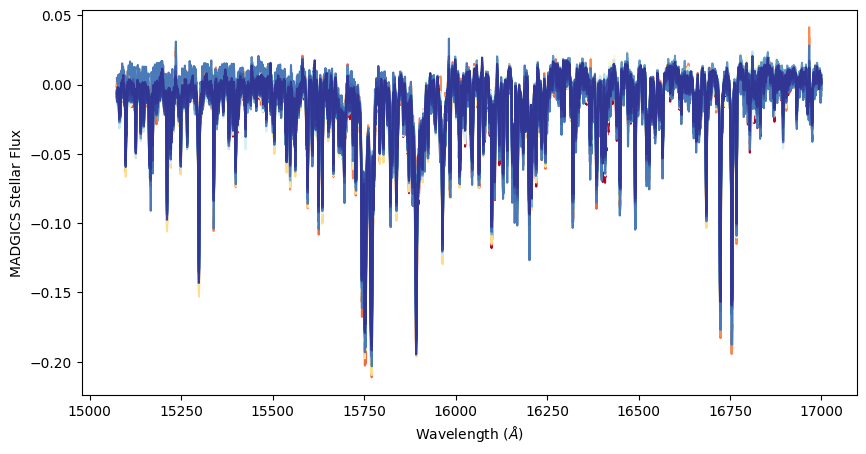

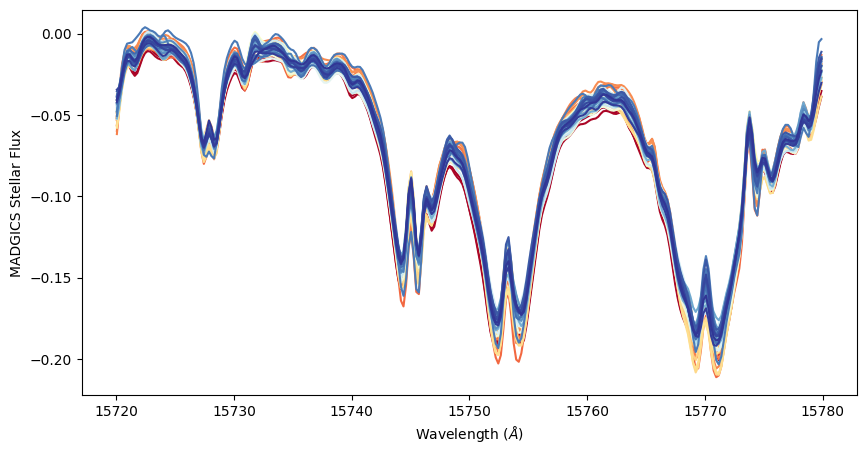

In [9]:
colors = plt.cm.RdYlBu(np.linspace(0,1,len(mjd)))

#plot all spectra (stellar component) for this star across the different observations in rest frame
plt.figure(figsize=(10,5))
for j in range(len(mjd)):
    if not good_data[j]:
        #skip the spectra with potentially bad flags
        continue
    plt.plot(uni_wave_APOGEE,star_fluxes_rest[j],c=colors[j])
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('MADGICS Stellar Flux')
plt.show()

#zoom in on one region
keep = np.abs(uni_wave_APOGEE-15750)<30
plt.figure(figsize=(10,5))
for j in range(len(mjd)):
    if not good_data[j]:
        #skip the spectra with potentially bad flags
        continue
    plt.plot(uni_wave_APOGEE[keep],star_fluxes_rest[j][keep],c=colors[j])
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('MADGICS Stellar Flux')
plt.show()

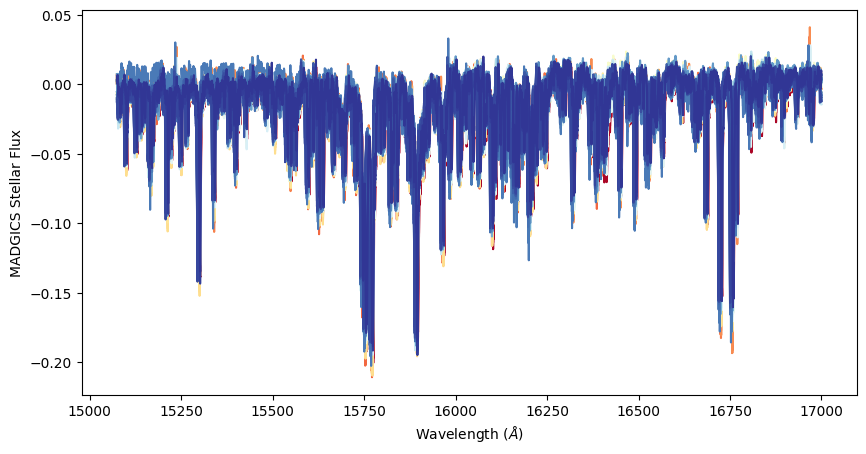

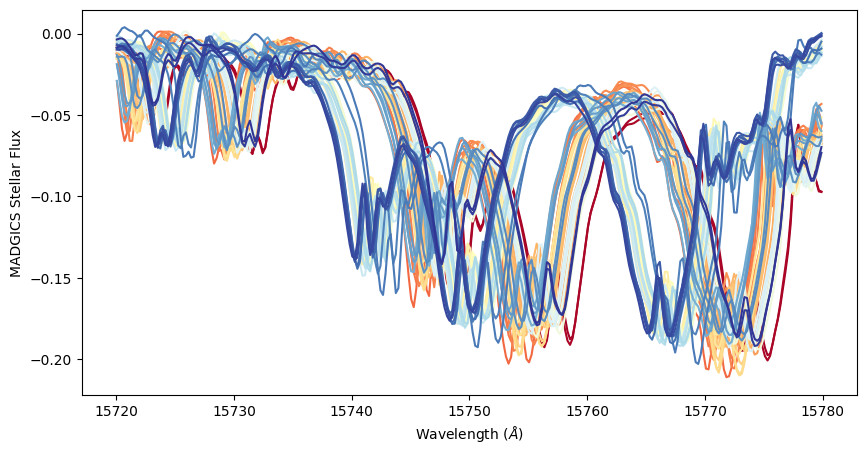

In [10]:
colors = plt.cm.RdYlBu(np.linspace(0,1,len(mjd)))

#plot all spectra (stellar component) for this star across the different observations in observer frame
plt.figure(figsize=(10,5))
for j in range(len(mjd)):
    if not good_data[j]:
        #skip the spectra with potentially bad flags
        continue
    plt.plot(uni_wave_APOGEE,star_fluxes_obs[j],c=colors[j])
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('MADGICS Stellar Flux')
plt.show()

#zoom in on one region
keep = np.abs(uni_wave_APOGEE-15750)<30
plt.figure(figsize=(10,5))
for j in range(len(mjd)):
    if not good_data[j]:
        #skip the spectra with potentially bad flags
        continue
    plt.plot(uni_wave_APOGEE[keep],star_fluxes_obs[j][keep],c=colors[j])
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('MADGICS Stellar Flux')
plt.show()